# Gradient Boosting

In [2]:
import pandas as pd

df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
X = df.iloc[:, [2, 3]].values    # Age, EstimatedSalary
y = df.iloc[:, -1].values


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

base_model = DecisionTreeClassifier(max_depth=3)

classifier = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1, max_depth=3, random_state=42)

In [7]:
classifier.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [8]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

y_pred = classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred) )

Accuracy: 0.8625
Confusion Matrix:
 [[47  5]
 [ 6 22]]


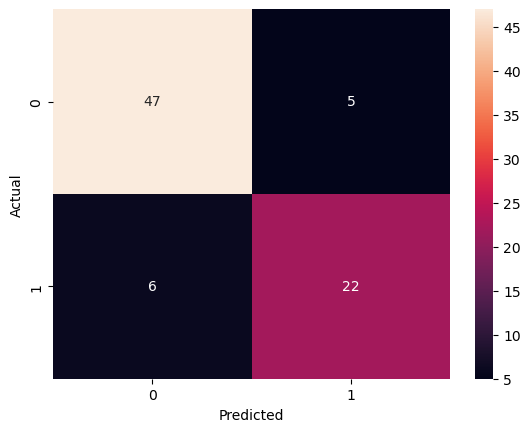

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()